In [1]:
import pandas as pd
import numpy as np

# 1. Load Users
users_cols = ['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code']
users = pd.read_csv('ml-1m/users.dat', sep='::', header=None, names=users_cols, engine='python', encoding='latin-1')

# 2. Load Movies
movies_cols = ['MovieID', 'Title', 'Genres']
movies = pd.read_csv('ml-1m/movies.dat', sep='::', header=None, names=movies_cols, engine='python', encoding='latin-1')

# 3. Load Ratings
ratings_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
ratings = pd.read_csv('ml-1m/ratings.dat', sep='::', header=None, names=ratings_cols, engine='python', encoding='latin-1')

# 4. Merge them all together into a master dataframe
data = pd.merge(pd.merge(ratings, users), movies)

# Take a look at the first 5 rows
data.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [2]:
import re

# Extract the 4-digit year from the Title string using Regular Expressions
data['Year'] = data['Title'].str.extract(r'\((\d{4})\)').astype(int)

# Let's drop the Timestamp and Zip-code for now to keep things clean
data = data.drop(columns=['Timestamp', 'Zip-code'])

In [3]:
# Extract the first genre from the string to act as the primary category
data['PrimaryGenre'] = data['Genres'].apply(lambda x: x.split('|')[0])

In [4]:
# Convert Age to string so we can concatenate it
data['Age'] = data['Age'].astype(str)

# Cross 1: Age + Primary Genre (e.g., "18_Action")
data['Age_Genre'] = data['Age'] + "_" + data['PrimaryGenre']

# Cross 2: Gender + Primary Genre (e.g., "M_Action")
data['Gender_Genre'] = data['Gender'] + "_" + data['PrimaryGenre']

In [5]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Encode Sparse IDs into dense 0-indexed integers
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

data['User_Idx'] = user_encoder.fit_transform(data['UserID'])
data['Movie_Idx'] = movie_encoder.fit_transform(data['MovieID'])

# 2. Normalize the 'Year' column (Neural networks hate large numbers like 1995)
# This will scale all years to be between 0.0 and 1.0
scaler = MinMaxScaler()
data['Year_Scaled'] = scaler.fit_transform(data[['Year']])

# Let's peek at our masterpiece
print(data[['User_Idx', 'Movie_Idx', 'Gender_Genre', 'Age_Genre', 'Year_Scaled', 'Rating']].head())

   User_Idx  Movie_Idx Gender_Genre    Age_Genre  Year_Scaled  Rating
0         0       1104      F_Drama      1_Drama     0.691358       5
1         0        639  F_Animation  1_Animation     0.950617       3
2         0        853    F_Musical    1_Musical     0.555556       3
3         0       3177      F_Drama      1_Drama     1.000000       4
4         0       2162  F_Animation  1_Animation     0.975309       5


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Encode the crossed strings into integers
ag_encoder = LabelEncoder()
data['Age_Genre_Idx'] = ag_encoder.fit_transform(data['Age_Genre'])

gg_encoder = LabelEncoder()
data['Gender_Genre_Idx'] = gg_encoder.fit_transform(data['Gender_Genre'])

# 2. Re-split the data so the new columns are included in train and test sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Get the total number of unique categories to define our neural network layer sizes
num_users = len(user_encoder.classes_)
num_movies = len(movie_encoder.classes_)
num_ag = len(ag_encoder.classes_)
num_gg = len(gg_encoder.classes_)

print(f"Vocab sizes -> Users: {num_users}, Movies: {num_movies}, Age_Genre: {num_ag}, Gender_Genre: {num_gg}")

Vocab sizes -> Users: 6040, Movies: 3706, Age_Genre: 126, Gender_Genre: 36


In [7]:
print(f"Training rows: {len(train_data)}")
print(f"Testing rows: {len(test_data)}")

Training rows: 800167
Testing rows: 200042


In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model

# ==========================================
# 1. DEFINE THE INPUTS
# ==========================================
user_input = Input(shape=(1,), name='User_Idx')
movie_input = Input(shape=(1,), name='Movie_Idx')
year_input = Input(shape=(1,), name='Year_Scaled')
age_genre_input = Input(shape=(1,), name='Age_Genre_Idx')
gender_genre_input = Input(shape=(1,), name='Gender_Genre_Idx')

# ==========================================
# 2. THE WIDE PATH (FTRL Target)
# ==========================================
# Notice all layers here start with "Wide_"
wide_ag = Embedding(input_dim=num_ag, output_dim=1, name='Wide_Age_Genre')(age_genre_input)
wide_gg = Embedding(input_dim=num_gg, output_dim=1, name='Wide_Gender_Genre')(gender_genre_input)

wide_path = Concatenate(name='Wide_Concat')([Flatten()(wide_ag), Flatten()(wide_gg)])

# ==========================================
# 3. THE DEEP PATH (AdaGrad Target)
# ==========================================
# Notice all layers here start with "Deep_"
user_emb = Embedding(input_dim=num_users, output_dim=32, name='Deep_User_Emb')(user_input)
movie_emb = Embedding(input_dim=num_movies, output_dim=32, name='Deep_Movie_Emb')(movie_input)

deep_path = Concatenate(name='Deep_Concat')([Flatten()(user_emb), Flatten()(movie_emb), year_input])
deep_path = Dense(64, activation='relu', name='Deep_Dense_1')(deep_path)
deep_path = Dense(32, activation='relu', name='Deep_Dense_2')(deep_path)

# ==========================================
# 4. FUSION
# ==========================================
combined = Concatenate(name='Fusion_Concat')([wide_path, deep_path])

# We group the final output node with the Deep optimizer
output = Dense(1, activation='linear', name='Deep_Rating_Prediction')(combined)

model = Model(inputs=[user_input, movie_input, year_input, age_genre_input, gender_genre_input], outputs=output)

# We do NOT compile the model here, because we are writing a custom training loop!
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ User_Idx            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Movie_Idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_User_Emb       │ (None, 1, 32)     │    193,280 │ User_Idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Movie_Emb      │ (None, 1, 32)     │    118,592 │ Movie_Idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Age_Genre_Idx       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Gender_Genre_Idx    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ Deep_User_Emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ Deep_Movie_Emb[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Year_Scaled         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wide_Age_Genre      │ (None, 1, 1)      │        126 │ Age_Genre_Idx[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wide_Gender_Genre   │ (None, 1, 1)      │         36 │ Gender_Genre_Idx… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Concat         │ (None, 65)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ Year_Scaled[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ Wide_Age_Genre[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1)         │          0 │ Wide_Gender_Genr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Dense_1        │ (None, 64)        │      4,224 │ Deep_Concat[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wide_Concat         │ (None, 2)         │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Dense_2        │ (None, 32)        │      2,080 │ Deep_Dense_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fusion_Concat       │ (None, 34)        │          0 │ Wide_Concat[0][0

 Total params: 318,373 (1.21 MB)

 Trainable params: 318,373 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import time
import tensorflow as tf

# 1. Package the training data into a dictionary
train_inputs = {
    'User_Idx': train_data['User_Idx'].values,
    'Movie_Idx': train_data['Movie_Idx'].values,
    'Year_Scaled': train_data['Year_Scaled'].values,
    'Age_Genre_Idx': train_data['Age_Genre_Idx'].values,
    'Gender_Genre_Idx': train_data['Gender_Genre_Idx'].values
}
train_labels = train_data['Rating'].values

# 2. Package the testing data into a dictionary
test_inputs = {
    'User_Idx': test_data['User_Idx'].values,
    'Movie_Idx': test_data['Movie_Idx'].values,
    'Year_Scaled': test_data['Year_Scaled'].values,
    'Age_Genre_Idx': test_data['Age_Genre_Idx'].values,
    'Gender_Genre_Idx': test_data['Gender_Genre_Idx'].values
}
test_labels = test_data['Rating'].values

# 3. Convert our training dictionary into a high-performance tf.data.Dataset
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
train_dataset = train_dataset.shuffle(buffer_size=10000).batch(batch_size)

# 4. Define the exact optimizers used in the Google Paper
# FTRL gets L1 regularization to ensure sparsity in the memorized rules
optimizer_wide = tf.keras.optimizers.Ftrl(learning_rate=0.01, l1_regularization_strength=0.001)
optimizer_deep = tf.keras.optimizers.Adagrad(learning_rate=0.01)

# We are predicting a continuous rating (1-5), so we use Mean Squared Error
loss_fn = tf.keras.losses.MeanSquaredError()

# 5. Create a custom training step function
@tf.function
def train_step(inputs, labels):
    with tf.GradientTape() as tape:
        # Forward pass: make predictions
        predictions = model(inputs, training=True)
        # Calculate how far off the predictions were
        loss = loss_fn(labels, predictions)

    # Calculate gradients for the entire model
    gradients = tape.gradient(loss, model.trainable_variables)

    # Separate the variables and their corresponding gradients based on layer names
    wide_vars = []
    wide_grads = []
    deep_vars = []
    deep_grads = []

    for grad, var in zip(gradients, model.trainable_variables):
        # Keras 3 Fix: Check 'path' if it exists, otherwise fallback to 'name'
        name_to_check = getattr(var, 'path', var.name)
        
        if 'Wide_' in name_to_check:
            wide_vars.append(var)
            wide_grads.append(grad)
        else:
            # Everything else (Deep_ layers and Fusion) goes to the Deep optimizer
            deep_vars.append(var)
            deep_grads.append(grad)

    # Apply the FTRL optimizer strictly to the Wide layers
    if wide_grads:
        optimizer_wide.apply_gradients(zip(wide_grads, wide_vars))
        
    # Apply the AdaGrad optimizer strictly to the Deep layers
    if deep_grads:
        optimizer_deep.apply_gradients(zip(deep_grads, deep_vars))

    return loss

# 6. Execute the Training Loop
epochs = 5

print("Starting custom training loop with FTRL (Wide) and AdaGrad (Deep)...")
for epoch in range(epochs):
    start_time = time.time()
    epoch_loss_avg = tf.keras.metrics.Mean()

    # Iterate over the batches of the dataset
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
        loss_value = train_step(x_batch_train, y_batch_train)
        epoch_loss_avg.update_state(loss_value)
        
        # Print progress every 500 batches
        if step % 500 == 0:
            print(f"Epoch {epoch + 1} - Step {step} - Batch Loss: {float(loss_value):.4f}")

    print(f"Epoch {epoch + 1} completed in {time.time() - start_time:.2f}s - Average Loss (MSE): {float(epoch_loss_avg.result()):.4f}")

Starting custom training loop with FTRL (Wide) and AdaGrad (Deep)...
Epoch 1 - Step 0 - Batch Loss: 13.2336
Epoch 1 - Step 500 - Batch Loss: 1.0351
Epoch 1 - Step 1000 - Batch Loss: 0.9767
Epoch 1 - Step 1500 - Batch Loss: 0.8151
Epoch 1 - Step 2000 - Batch Loss: 0.9841
Epoch 1 - Step 2500 - Batch Loss: 0.8541
Epoch 1 - Step 3000 - Batch Loss: 1.0445
Epoch 1 completed in 7.99s - Average Loss (MSE): 1.0605
Epoch 2 - Step 0 - Batch Loss: 0.7936
Epoch 2 - Step 500 - Batch Loss: 0.8522
Epoch 2 - Step 1000 - Batch Loss: 0.8434
Epoch 2 - Step 1500 - Batch Loss: 0.8162
Epoch 2 - Step 2000 - Batch Loss: 0.8476
Epoch 2 - Step 2500 - Batch Loss: 0.8030
Epoch 2 - Step 3000 - Batch Loss: 0.9435
Epoch 2 completed in 7.56s - Average Loss (MSE): 0.8365
Epoch 3 - Step 0 - Batch Loss: 0.8217
Epoch 3 - Step 500 - Batch Loss: 0.7769
Epoch 3 - Step 1000 - Batch Loss: 0.8005
Epoch 3 - Step 1500 - Batch Loss: 0.8600
Epoch 3 - Step 2000 - Batch Loss: 0.7638
Epoch 3 - Step 2500 - Batch Loss: 0.8958
Epoch 3 - 

In [10]:
import joblib # Used for saving our scikit-learn encoders

# 1. Evaluate on the Test Set
print("Evaluating on test data...")
# We use the same loss function (Mean Squared Error) defined earlier
test_predictions = model.predict(test_inputs, batch_size=256)
test_mse = loss_fn(test_labels, test_predictions)
print(f"Final Test MSE: {float(test_mse):.4f}")

# 2. Save the trained TensorFlow model
model.save("wide_and_deep_model.keras")
print("Model saved to 'wide_and_deep_model.keras'")

# 3. Save the Encoders so our API can use them later
joblib.dump(user_encoder, "user_encoder.pkl")
joblib.dump(movie_encoder, "movie_encoder.pkl")
joblib.dump(ag_encoder, "ag_encoder.pkl")
joblib.dump(gg_encoder, "gg_encoder.pkl")
print("Encoders saved successfully!")

Evaluating on test data...
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 728us/step
Final Test MSE: 0.8288
Model saved to 'wide_and_deep_model.keras'
Encoders saved successfully!


In [11]:
# Grab the first 10 rows from our test data dictionaries
sample_size = 10

sample_inputs = {
    'User_Idx': test_inputs['User_Idx'][:sample_size],
    'Movie_Idx': test_inputs['Movie_Idx'][:sample_size],
    'Year_Scaled': test_inputs['Year_Scaled'][:sample_size],
    'Age_Genre_Idx': test_inputs['Age_Genre_Idx'][:sample_size],
    'Gender_Genre_Idx': test_inputs['Gender_Genre_Idx'][:sample_size]
}

# Grab the actual true ratings for those 10 rows
actual_ratings = test_labels[:sample_size]

# Ask the model to predict the ratings
print("Running predictions...\n")
predicted_ratings = model.predict(sample_inputs, verbose=0)

# Print the comparison neatly
print("-" * 60)
print(f"{'Row':<5} | {'Actual Rating':<15} | {'Predicted Rating':<15}")
print("-" * 60)

for i in range(sample_size):
    # The model outputs a 2D array, so we grab the [0] index to get the raw number
    pred = predicted_ratings[i][0]
    actual = actual_ratings[i]
    
    # We round the prediction to 2 decimal places for readability
    print(f"{i+1:<5} | {actual:<15} | {pred:.2f}")
    
print("-" * 60)

Running predictions...

------------------------------------------------------------
Row   | Actual Rating   | Predicted Rating
------------------------------------------------------------
1     | 2               | 3.61
2     | 5               | 4.87
3     | 4               | 3.40
4     | 4               | 3.37
5     | 1               | 2.76
6     | 4               | 3.65
7     | 5               | 2.29
8     | 3               | 2.82
9     | 1               | 3.12
10    | 1               | 2.67
------------------------------------------------------------


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Function to build the model dynamically
def create_experiment_model(deep_activation='relu'):
    user_input = Input(shape=(1,), name='User_Idx')
    movie_input = Input(shape=(1,), name='Movie_Idx')
    year_input = Input(shape=(1,), name='Year_Scaled')
    age_genre_input = Input(shape=(1,), name='Age_Genre_Idx')
    gender_genre_input = Input(shape=(1,), name='Gender_Genre_Idx')

    wide_ag = Embedding(input_dim=num_ag, output_dim=1, name='Wide_Age_Genre')(age_genre_input)
    wide_gg = Embedding(input_dim=num_gg, output_dim=1, name='Wide_Gender_Genre')(gender_genre_input)
    wide_path = Concatenate(name='Wide_Concat')([Flatten()(wide_ag), Flatten()(wide_gg)])

    user_emb = Embedding(input_dim=num_users, output_dim=32, name='Deep_User_Emb')(user_input)
    movie_emb = Embedding(input_dim=num_movies, output_dim=32, name='Deep_Movie_Emb')(movie_input)
    deep_path = Concatenate(name='Deep_Concat')([Flatten()(user_emb), Flatten()(movie_emb), year_input])
    deep_path = Dense(64, activation=deep_activation, name='Deep_Dense_1')(deep_path)
    deep_path = Dense(32, activation=deep_activation, name='Deep_Dense_2')(deep_path)

    combined = Concatenate(name='Fusion_Concat')([wide_path, deep_path])
    output = Dense(1, activation='linear', name='Deep_Rating_Prediction')(combined)

    return Model(inputs=[user_input, movie_input, year_input, age_genre_input, gender_genre_input], outputs=output)

# 2. Function to train the model and return the loss history
def train_experiment(model, opt_wide, opt_deep, epochs=5):
    history_loss = []
    
    @tf.function
    def step_fn(inputs, labels):
        with tf.GradientTape() as tape:
            preds = model(inputs, training=True)
            loss = loss_fn(labels, preds)
        
        grads = tape.gradient(loss, model.trainable_variables)
        wide_vars, wide_grads, deep_vars, deep_grads = [], [], [], []
        
        for grad, var in zip(grads, model.trainable_variables):
            if 'Wide_' in getattr(var, 'path', var.name):
                wide_vars.append(var)
                wide_grads.append(grad)
            else:
                deep_vars.append(var)
                deep_grads.append(grad)
                
        if wide_grads: opt_wide.apply_gradients(zip(wide_grads, wide_vars))
        if deep_grads: opt_deep.apply_gradients(zip(deep_grads, deep_vars))
        return loss

    print("Training started...")
    for epoch in range(epochs):
        epoch_loss_avg = tf.keras.metrics.Mean()
        for x_batch, y_batch in train_dataset:
            loss_val = step_fn(x_batch, y_batch)
            epoch_loss_avg.update_state(loss_val)
        
        avg_loss = float(epoch_loss_avg.result())
        history_loss.append(avg_loss)
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
        
    return history_loss

# 3. Function to mathematically prove the FTRL Sparsity
def calculate_sparsity(model):
    total_weights = 0
    zero_weights = 0
    for var in model.trainable_variables:
        if 'Wide_' in getattr(var, 'path', var.name):
            weights = var.numpy()
            total_weights += weights.size
            # Count weights that are exactly 0.0
            zero_weights += np.sum(weights == 0.0) 
    
    return (zero_weights / total_weights) * 100 if total_weights > 0 else 0

In [16]:
print("--- EXPERIMENT 1: The Champion (FTRL + AdaGrad + ReLU) ---")
model_champ = create_experiment_model(deep_activation='relu')
opt_wide_champ = tf.keras.optimizers.Ftrl(learning_rate=0.01, l1_regularization_strength=0.5)
opt_deep_champ = tf.keras.optimizers.Adagrad(learning_rate=0.01)
hist_champ = train_experiment(model_champ, opt_wide_champ, opt_deep_champ, epochs=5)
sparsity_champ = calculate_sparsity(model_champ)

print("\n--- EXPERIMENT 2: The Challenger (Adam + Adam + ReLU) ---")
model_adam = create_experiment_model(deep_activation='relu')
# We use Adam for both wide and deep here
opt_wide_adam = tf.keras.optimizers.Adam(learning_rate=0.001) 
opt_deep_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
hist_adam = train_experiment(model_adam, opt_wide_adam, opt_deep_adam, epochs=5)
sparsity_adam = calculate_sparsity(model_adam)

print("\n--- EXPERIMENT 3: The Legacy Network (FTRL + SGD + Sigmoid) ---")
# Using the old Sigmoid activation and standard Stochastic Gradient Descent
model_legacy = create_experiment_model(deep_activation='sigmoid')
opt_wide_legacy = tf.keras.optimizers.Ftrl(learning_rate=0.01, l1_regularization_strength=0.001)
opt_deep_legacy = tf.keras.optimizers.SGD(learning_rate=0.01)
hist_legacy = train_experiment(model_legacy, opt_wide_legacy, opt_deep_legacy, epochs=5)

--- EXPERIMENT 1: The Champion (FTRL + AdaGrad + ReLU) ---
Training started...
  Epoch 1/5 - Loss: 1.0545
  Epoch 2/5 - Loss: 0.8345
  Epoch 3/5 - Loss: 0.8205
  Epoch 4/5 - Loss: 0.8150
  Epoch 5/5 - Loss: 0.8116

--- EXPERIMENT 2: The Challenger (Adam + Adam + ReLU) ---
Training started...
  Epoch 1/5 - Loss: 0.9660
  Epoch 2/5 - Loss: 0.7777
  Epoch 3/5 - Loss: 0.7328
  Epoch 4/5 - Loss: 0.6949
  Epoch 5/5 - Loss: 0.6645

--- EXPERIMENT 3: The Legacy Network (FTRL + SGD + Sigmoid) ---
Training started...
  Epoch 1/5 - Loss: 1.2451
  Epoch 2/5 - Loss: 1.2107
  Epoch 3/5 - Loss: 1.2031
  Epoch 4/5 - Loss: 1.1967
  Epoch 5/5 - Loss: 1.1890


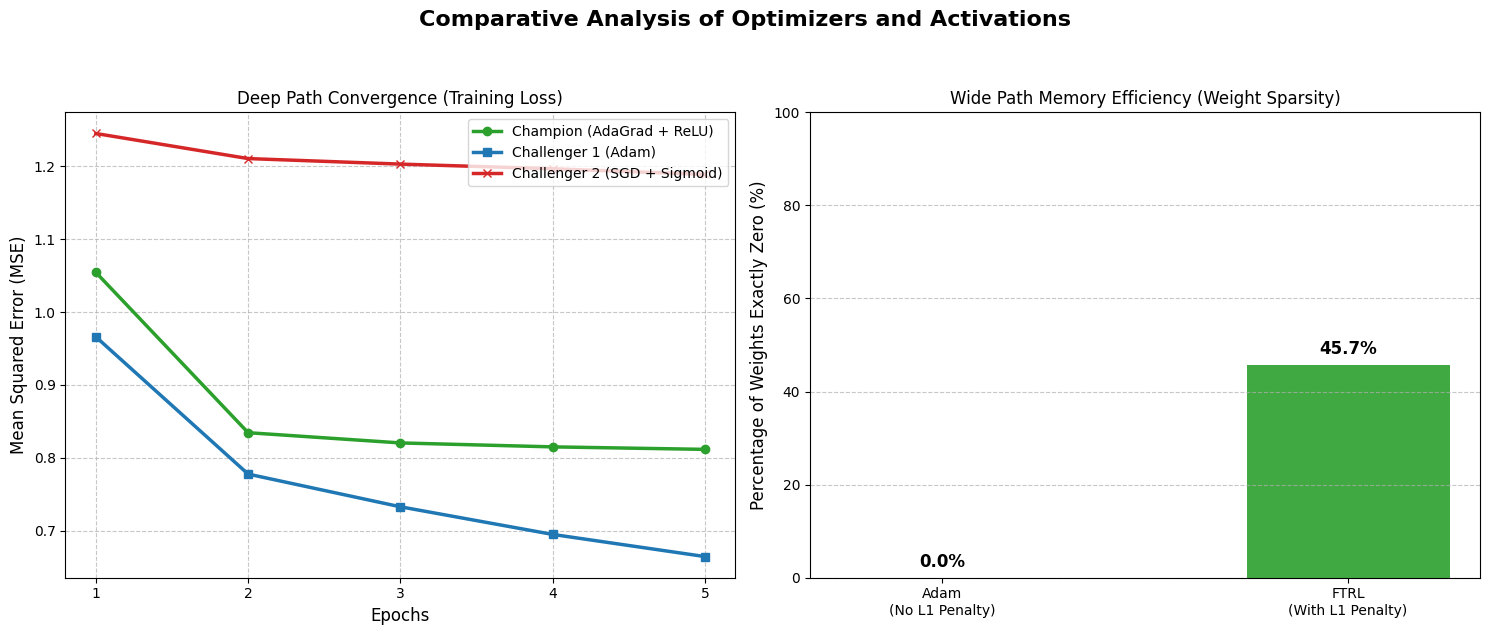

In [17]:
# Set up the figure for 2 plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Comparative Analysis of Optimizers and Activations', fontsize=16, fontweight='bold', y=1.05)

# --- PLOT 1: Convergence Curve ---
epochs_range = range(1, 6)
ax1.plot(epochs_range, hist_champ, marker='o', color='#2ca02c', linewidth=2.5, label='Champion (AdaGrad + ReLU)')
ax1.plot(epochs_range, hist_adam, marker='s', color='#1f77b4', linewidth=2.5, label='Challenger 1 (Adam)')
ax1.plot(epochs_range, hist_legacy, marker='x', color='#d62728', linewidth=2.5, label='Challenger 2 (SGD + Sigmoid)')

ax1.set_title('Deep Path Convergence (Training Loss)')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax1.set_xticks(epochs_range)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.7)

# --- PLOT 2: Memory Efficiency (Sparsity) ---
models = ['Adam\n(No L1 Penalty)', 'FTRL\n(With L1 Penalty)']
sparsity_vals = [sparsity_adam, sparsity_champ]

bars = ax2.bar(models, sparsity_vals, color=['#1f77b4', '#2ca02c'], width=0.5, alpha=0.9)
ax2.set_title('Wide Path Memory Efficiency (Weight Sparsity)')
ax2.set_ylabel('Percentage of Weights Exactly Zero (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact percentage text on top of the bars
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5),  # 5 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Calculate the Model's RMSE
# We already generated 'test_predictions' and 'test_labels' in an earlier cell!
model_mse = mean_squared_error(test_labels, test_predictions)
model_rmse = np.sqrt(model_mse)

# 2. Establish a "Naive Baseline"
# What if we built a completely dumb model that just predicts the global average rating every time?
global_average_rating = train_labels.mean()

# Create an array of predictions that is just the average rating, repeated for every test row
baseline_predictions = np.full_like(test_labels, global_average_rating, dtype=float)
baseline_mse = mean_squared_error(test_labels, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)

# 3. Print the Academic Report
print("--- RIGOROUS ACADEMIC EVALUATION (ROOT MEAN SQUARE ERROR) ---")
print(f"Global Average Movie Rating:  {global_average_rating:.2f} ⭐")
print(f"Baseline RMSE (Dumb Guess):   {baseline_rmse:.4f}")
print(f"Wide & Deep Model RMSE:       {model_rmse:.4f}")
print("-" * 60)

# Calculate the percentage improvement
improvement = ((baseline_rmse - model_rmse) / baseline_rmse) * 100
print(f"The Wide & Deep architecture improved the error rate by {improvement:.2f}% over the baseline.")

--- RIGOROUS ACADEMIC EVALUATION (ROOT MEAN SQUARE ERROR) ---
Global Average Movie Rating:  3.58 ⭐
Baseline RMSE (Dumb Guess):   1.1197
Wide & Deep Model RMSE:       0.9104
------------------------------------------------------------
The Wide & Deep architecture improved the error rate by 18.70% over the baseline.


--- ADVANCED REGRESSION METRICS ---
Mean Absolute Error (MAE): 0.7208 ⭐
R-Squared (R2) Score:      0.3389
-----------------------------------


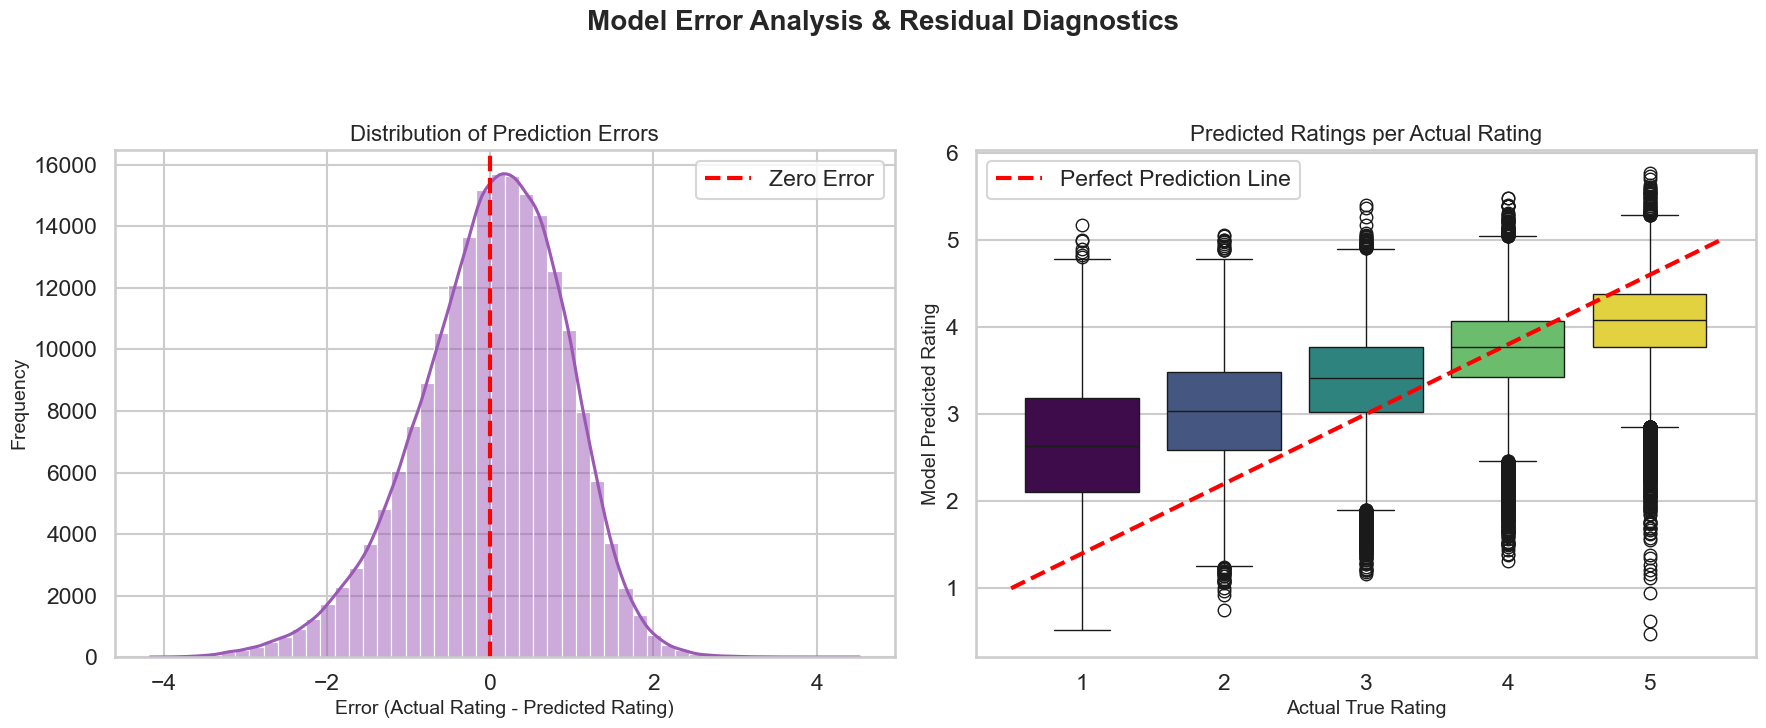

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make the graphs larger and presentation-ready
sns.set_theme(style="whitegrid", context="talk")

# Ensure predictions are flattened to a 1D array
flat_predictions = test_predictions.flatten()
flat_labels = test_labels.flatten()

# --- 1. CALCULATE ADDITIONAL STATS ---
model_mae = mean_absolute_error(flat_labels, flat_predictions)
model_r2 = r2_score(flat_labels, flat_predictions)

print("--- ADVANCED REGRESSION METRICS ---")
print(f"Mean Absolute Error (MAE): {model_mae:.4f} ⭐")
print(f"R-Squared (R2) Score:      {model_r2:.4f}")
print("-" * 35)

# --- 2. GENERATE EVALUATION GRAPHS ---
residuals = flat_labels - flat_predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Error Analysis & Residual Diagnostics', fontsize=20, fontweight='bold', y=1.05)

# Graph 1: Residual Distribution (The Bell Curve)
sns.histplot(residuals, bins=50, kde=True, color='#9b59b6', ax=ax1)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=3, label='Zero Error')
ax1.set_title('Distribution of Prediction Errors', fontsize=16)
ax1.set_xlabel('Error (Actual Rating - Predicted Rating)', fontsize=14)
ax1.set_ylabel('Frequency', fontsize=14)
ax1.legend()

# Graph 2: Actual vs Predicted Box Plot (Warning Fixed!)
# Added hue=flat_labels and legend=False to comply with new Seaborn standards
sns.boxplot(x=flat_labels, y=flat_predictions, hue=flat_labels, palette='viridis', legend=False, ax=ax2)
ax2.plot([-0.5, 4.5], [1, 5], color='red', linestyle='--', linewidth=3, label='Perfect Prediction Line')
ax2.set_title('Predicted Ratings per Actual Rating', fontsize=16)
ax2.set_xlabel('Actual True Rating', fontsize=14)
ax2.set_ylabel('Model Predicted Rating', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()